In [2]:
# Librerías
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import association_rules

In [3]:
# Datos
# ==============================================================================
url = (
    "https://raw.githubusercontent.com/JoaquinAmatRodrigo/Estadistica-con-R/"
    "master/datos/datos_groceries.csv"
)
datos = pd.read_csv(url)
datos.head()

,id_compra,item
0,1,citrus fruit
1,1,semi-finished bread
2,1,margarine
3,1,ready soups
4,2,tropical fruit


In [4]:
# Ítems de la transacción 14
# ==============================================================================
datos.query("id_compra==14")

,id_compra,item
45,14,frankfurter
46,14,rolls/buns
47,14,soda


In [5]:
# Total de transacciones e ítems (productos)
# ==============================================================================
print(f"Número total de transacciones: {datos['id_compra'].nunique()}")
print(f"Número total de ítems (productos): {datos['item'].nunique()}")

Número total de transacciones: 9835
Número total de ítems (productos): 169


In [6]:
# Ítems (productos) agrupados por transacción (compra)
# ==============================================================================
datos.groupby('id_compra')['item'].apply(list)

id_compra
1       [citrus fruit, semi-finished bread, margarine,...
2                        [tropical fruit, yogurt, coffee]
3                                            [whole milk]
4         [pip fruit, yogurt, cream cheese, meat spreads]
5       [other vegetables, whole milk, condensed milk,...
                              ...                        
9831    [sausage, chicken, beef, hamburger meat, citru...
9832                                  [cooking chocolate]
9833    [chicken, citrus fruit, other vegetables, butt...
9834    [semi-finished bread, bottled water, soda, bot...
9835    [chicken, tropical fruit, other vegetables, vi...
Name: item, Length: 9835, dtype: object

count    9835.000000
mean        4.409456
std         3.589385
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
90%         9.000000
max        32.000000
Name: item, dtype: float64

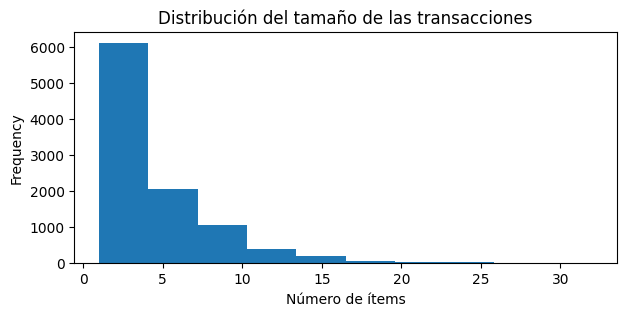

In [7]:
# Distribución del número de ítems por transacción
# ==============================================================================
display(datos.groupby('id_compra')['item'].size().describe(percentiles=[.25, .5, .75, .9]))

fig, ax = plt.subplots(figsize=(7, 3))
datos.groupby('id_compra')['item'].size().plot.hist(ax=ax)
ax.set_title('Distribución del tamaño de las transacciones');
ax.set_xlabel('Número de ítems');

In [8]:
# Codificar las transacciones en forma de matriz binaria
# ==============================================================================
# Crear una lista de listas que contenga los ítems de cada transacción
transacciones = datos.groupby('id_compra')['item'].apply(list).to_list()

# Entrenar el objeto TransactionEncoder y transformar los datos
encoder = TransactionEncoder()
transacciones_encoded = encoder.fit(transacciones).transform(transacciones)
transacciones_encoded = pd.DataFrame(transacciones_encoded, columns=encoder.columns_)
transacciones_encoded.head(3)

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [9]:
# Porcentaje de transacciones en las que aparece cada producto (top 5)
# ==============================================================================
transacciones_encoded.mean(axis = 0).sort_values(ascending = False).head(5)

whole milk          0.255516
other vegetables    0.193493
rolls/buns          0.183935
soda                0.174377
yogurt              0.139502
dtype: float64

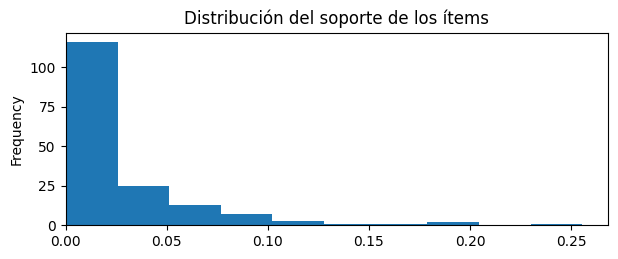

In [10]:
# Distribución del sopoerte de los items
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 2.5))
transacciones_encoded.mean(axis = 0).plot.hist(ax = ax)
ax.set_xlim(0, )
ax.set_title('Distribución del soporte de los ítems');

In [11]:
# Codificar las transacciones en forma de matriz binaria
# ==============================================================================
# Crear una lista de listas que contenga los artículos comprados en cada transacción
transacciones = datos.groupby('id_compra')['item'].apply(list).to_list()

# Entrenar el objeto TransactionEncoder y transformar los datos
encoder = TransactionEncoder()
transacciones_encoded = encoder.fit(transacciones).transform(transacciones)
transacciones_encoded = pd.DataFrame(transacciones_encoded, columns=encoder.columns_)
transacciones_encoded.head(3)

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [12]:

# Identificación de itemsets frecuentes
# ==============================================================================
soporte = 30 / transacciones_encoded.shape[0]
print(f"Soporte mínimo: {soporte}")

itemsets = apriori(transacciones_encoded, min_support=soporte, use_colnames=True)
itemsets.sort_values(by='support', ascending=False)

Soporte mínimo: 0.003050330452465684


,support,itemsets
133,0.255516,(whole milk)
83,0.193493,(other vegetables)
98,0.183935,(rolls/buns)
111,0.174377,(soda)
134,0.139502,(yogurt)
...,...,...
1439,0.003050,"(butter, yogurt, citrus fruit)"
1601,0.003050,"(coffee, yogurt, tropical fruit)"
664,0.003050,"(dessert, margarine)"
1884,0.003050,"(sausage, newspapers, whole milk)"


In [13]:
# Top 10 itemsets con mayor soporte
# ==============================================================================
itemsets.sort_values(by='support', ascending=False).head(10)

,support,itemsets
133,0.255516,(whole milk)
83,0.193493,(other vegetables)
98,0.183935,(rolls/buns)
111,0.174377,(soda)
134,0.139502,(yogurt)
9,0.110524,(bottled water)
99,0.108998,(root vegetables)
126,0.104931,(tropical fruit)
107,0.098526,(shopping bags)
104,0.093950,(sausage)


In [14]:
# Top 10 itemsets con al menos 2 items, ordenados por soporte
# ==============================================================================
itemsets['n_items'] = itemsets['itemsets'].apply(lambda x: len(x))
itemsets.query('n_items >= 2').sort_values('support', ascending=False).head(10)

,support,itemsets,n_items
1076,0.074835,"(whole milk, other vegetables)",2
1171,0.056634,"(rolls/buns, whole milk)",2
1275,0.056024,"(yogurt, whole milk)",2
1185,0.048907,"(root vegetables, whole milk)",2
1055,0.047382,"(root vegetables, other vegetables)",2
1077,0.043416,"(yogurt, other vegetables)",2
1054,0.042603,"(rolls/buns, other vegetables)",2
1263,0.042298,"(tropical fruit, whole milk)",2
1240,0.040061,"(whole milk, soda)",2
1161,0.038332,"(rolls/buns, soda)",2


In [15]:
# Itemsets frecuentes que contienen el ítem newspapers
# ==============================================================================
mask = itemsets['itemsets'].map(lambda x: 'newspapers' in x)
itemsets.loc[mask].sort_values(by='support', ascending=False)

,support,itemsets,n_items
78,0.079817,(newspapers),1
1017,0.027351,"(newspapers, whole milk)",2
1006,0.019725,"(rolls/buns, newspapers)",2
1002,0.019319,"(newspapers, other vegetables)",2
1018,0.015353,"(yogurt, newspapers)",2
...,...,...,...
1876,0.003050,"(rolls/buns, sausage, newspapers)",3
1884,0.003050,"(sausage, newspapers, whole milk)",3
957,0.003050,"(meat, newspapers)",2
896,0.003050,"(hygiene articles, newspapers)",2


In [16]:
# Itemsets frecuentes que contienen los items, al menos, newspapers y whole milk
# ==============================================================================
items = {'newspapers', 'whole milk'}
mask = itemsets['itemsets'].map(lambda x: x.issuperset(items))
itemsets.loc[mask].sort_values(by='support', ascending=False).reset_index()

,index,support,itemsets,n_items
0,1017,0.027351,"(newspapers, whole milk)",2
1,1872,0.008338,"(newspapers, whole milk, other vegetables)",3
2,1879,0.007626,"(rolls/buns, newspapers, whole milk)",3
3,1889,0.006609,"(yogurt, newspapers, whole milk)",3
4,1882,0.005796,"(root vegetables, newspapers, whole milk)",3
5,1887,0.005084,"(tropical fruit, newspapers, whole milk)",3
6,1885,0.004779,"(newspapers, whole milk, soda)",3
7,1360,0.004067,"(newspapers, whole milk, bottled water)",3
8,1406,0.004067,"(brown bread, newspapers, whole milk)",3
9,1874,0.003864,"(pastry, newspapers, whole milk)",3


In [17]:
# Identificación subsets
# ==============================================================================
itemset_a = {'other vegetables', 'whole milk', 'newspapers'}
itemset_b = {'other vegetables', 'whole milk', 'newspapers'}

print(itemset_a.issubset(itemset_b))
print(itemset_b.issuperset(itemset_a))

True
True


In [18]:
# Identificación de itemsets frecuentes
# ==============================================================================
soporte = 30 / transacciones_encoded.shape[0]
itemsets_frecuentes = apriori(transacciones_encoded, min_support=soporte, use_colnames=True)

# Crear reglas de asociación (confianza mínima del 70% para que una regla sea selecionada)
# ==============================================================================
confianza = 0.7 
reglas = association_rules(itemsets_frecuentes, metric="confidence", min_threshold=confianza)

print(f"Número de reglas generadas: {len(reglas)}")
print(f"Confianza mínima: {reglas['confidence'].min()}")
print(f"Confianza máxima: {reglas['confidence'].max()}")
reglas.sort_values(by='confidence').head(5)

Número de reglas generadas: 19
Confianza mínima: 0.7000000000000001
Confianza máxima: 0.8857142857142858


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
14,"(tropical fruit, yogurt, root vegetables)",(whole milk),0.008134,0.255516,0.005694,0.700000,2.739554,1.0,0.003616,2.481613,0.640185,0.022073,0.597036,0.361142
12,"(domestic eggs, whipped/sour cream, other vege...",(whole milk),0.005084,0.255516,0.003559,0.700000,2.739554,1.0,0.002260,2.481613,0.638222,0.013845,0.597036,0.356964
1,"(coffee, butter)",(whole milk),0.004779,0.255516,0.003355,0.702128,2.747881,1.0,0.002134,2.499339,0.639138,0.013059,0.599894,0.357630
4,"(butter, pork)",(whole milk),0.005491,0.255516,0.003864,0.703704,2.754049,1.0,0.002461,2.512633,0.640415,0.015026,0.602011,0.359413
17,"(tropical fruit, citrus fruit, root vegetables...",(whole milk),0.004474,0.255516,0.003152,0.704545,2.757344,1.0,0.002009,2.519792,0.640196,0.012272,0.603142,0.358441


In [19]:
# Seleccionar reglas que tienen "other vegetables" en el consecuente
# ==============================================================================
mask = reglas['consequents'].map(lambda x: 'other vegetables' in x)
reglas.loc[mask]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
10,"(tropical fruit, citrus fruit, root vegetables)",(other vegetables),0.005694,0.193493,0.004474,0.785714,4.060694,1.0,0.003372,3.763701,0.758053,0.022977,0.734304,0.404418
13,"(tropical fruit, whipped/sour cream, root vege...",(other vegetables),0.004575,0.193493,0.003355,0.733333,3.789981,1.0,0.002470,3.024403,0.739530,0.017232,0.669356,0.375337
16,"(tropical fruit, citrus fruit, root vegetables...",(other vegetables),0.003559,0.193493,0.003152,0.885714,4.577509,1.0,0.002463,7.056940,0.784332,0.016256,0.858296,0.451002


In [20]:
# Antecedentes de las reglas que tienen "other vegetables" en el consecuente
# ==============================================================================
antecedents = reglas.loc[mask, 'antecedents'].to_list()
set().union(*antecedents)

{'citrus fruit',
 'root vegetables',
 'tropical fruit',
 'whipped/sour cream',
 'whole milk'}

In [21]:
# Crear una columna con los ítems que forman parte del antecedente y el consecuente
# ======================================================================================
reglas['items'] = reglas[['antecedents', 'consequents']].apply(lambda x: set().union(*x), axis=1)
reglas.head(3)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,items
0,"(yogurt, baking powder)",(whole milk),0.004575,0.255516,0.003254,0.711111,2.783039,1.0,0.002085,2.577060,0.643626,0.012668,0.611961,0.361922,"{yogurt, baking powder, whole milk}"
1,"(coffee, butter)",(whole milk),0.004779,0.255516,0.003355,0.702128,2.747881,1.0,0.002134,2.499339,0.639138,0.013059,0.599894,0.357630,"{coffee, butter, whole milk}"
2,"(curd, butter)",(whole milk),0.006812,0.255516,0.004881,0.716418,2.803808,1.0,0.003140,2.625286,0.647755,0.018957,0.619089,0.367759,"{curd, butter, whole milk}"


In [22]:
# Filtrar reglas
# ==============================================================================
seleccion_items = {'citrus fruit', 'root vegetables', 'tropical fruit',
                   'whole milk', 'other vegetables'}
mask = reglas['items'].map(lambda x: x.issubset(seleccion_items))
reglas.loc[mask]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,items
10,"(tropical fruit, citrus fruit, root vegetables)",(other vegetables),0.005694,0.193493,0.004474,0.785714,4.060694,1.0,0.003372,3.763701,0.758053,0.022977,0.734304,0.404418,"{tropical fruit, citrus fruit, root vegetables..."
16,"(tropical fruit, citrus fruit, root vegetables...",(other vegetables),0.003559,0.193493,0.003152,0.885714,4.577509,1.0,0.002463,7.056940,0.784332,0.016256,0.858296,0.451002,"{tropical fruit, citrus fruit, root vegetables..."
17,"(tropical fruit, citrus fruit, root vegetables...",(whole milk),0.004474,0.255516,0.003152,0.704545,2.757344,1.0,0.002009,2.519792,0.640196,0.012272,0.603142,0.358441,"{tropical fruit, citrus fruit, root vegetables..."


In [23]:
# Identificación de itemsets (2 items) frecuentes
# ==============================================================================
soporte = 30 / transacciones_encoded.shape[0]
itemsets_frecuentes = apriori(
                          transacciones_encoded, 
                          min_support  = soporte, 
                          use_colnames = True, 
                          max_len      = 2
                      )


In [24]:
# Calcular lift base
# ==============================================================================
lift = 0
reglas = association_rules(itemsets_frecuentes, metric="lift", min_threshold=lift)

print(f"Número de reglas generadas: {len(reglas)}")
print(f"Lift medio: {reglas['lift'].mean()}")
print(f"Lift mediano: {reglas['lift'].median()}")

Número de reglas generadas: 2280
Lift medio: 1.644958572425791
Lift mediano: 1.5504543534185435


In [25]:
# Crear reglas de asociación (lift mínimo de 1.6)
# ==============================================================================
lift = 1.6
reglas = association_rules(itemsets_frecuentes, metric="lift", min_threshold=lift)

print(f"Número de reglas generadas: {len(reglas)}")
print(f"Lift mínimo: {reglas['lift'].min()}")
print(f"Lift máximo: {reglas['lift'].max()}")
reglas.sort_values(by='lift').head(3)

Número de reglas generadas: 1044
Lift mínimo: 1.602248197776239
Lift máximo: 11.421437695970273


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
362,(coffee),(frozen vegetables),0.058058,0.048094,0.004474,0.077058,1.602248,1.0,0.001682,1.031383,0.399045,0.044000,0.030428,0.085041
363,(frozen vegetables),(coffee),0.048094,0.058058,0.004474,0.093023,1.602248,1.0,0.001682,1.038551,0.394868,0.044000,0.037120,0.085041
928,(yogurt),(pot plants),0.139502,0.017285,0.003864,0.027697,1.602341,1.0,0.001452,1.010708,0.436855,0.025266,0.010595,0.125613


In [26]:
# Filtrar por confianza mínima del 50%
# ==============================================================================
confianza = 0.5
reglas = reglas[reglas['confidence'] >= confianza]

print(f"Número de reglas generadas: {len(reglas)}")
print(f"Confianza mínima: {reglas['confidence'].min()}")
print(f"Confianza máxima: {reglas['confidence'].max()}")
reglas.sort_values(by='confidence').head(3)

Número de reglas generadas: 5
Confianza mínima: 0.5
Confianza máxima: 0.6428571428571428


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
870,(specialty cheese),(other vegetables),0.008541,0.193493,0.004270,0.500000,2.584078,1.0,0.002618,1.613015,0.618296,0.021594,0.380043,0.261035
857,(rice),(other vegetables),0.007626,0.193493,0.003965,0.520000,2.687441,1.0,0.002490,1.680224,0.632724,0.020113,0.404841,0.270247
36,(baking powder),(whole milk),0.017692,0.255516,0.009253,0.522989,2.046793,1.0,0.004732,1.560725,0.520642,0.035054,0.359272,0.279600


In [27]:
# Recomendaciones 1 a 1
# ==============================================================================
antecedente = 'rice'

mask = reglas['antecedents'].map(lambda x: antecedente in x)
reglas.loc[mask]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
857,(rice),(other vegetables),0.007626,0.193493,0.003965,0.520000,2.687441,1.0,0.002490,1.680224,0.632724,0.020113,0.404841,0.270247
945,(rice),(whole milk),0.007626,0.255516,0.004677,0.613333,2.400371,1.0,0.002729,1.925390,0.587881,0.018096,0.480625,0.315819


In [29]:
import session_info
session_info.show(html=False)

-----
matplotlib          3.9.4
mlxtend             0.23.4
pandas              2.2.3
seaborn             0.13.2
session_info        v1.0.1
-----
IPython             8.18.1
jupyter_client      8.6.3
jupyter_core        5.7.2
jupyterlab          4.3.6
notebook            7.3.3
-----
Python 3.9.6 (default, Nov 11 2024, 03:15:38) [Clang 16.0.0 (clang-1600.0.26.6)]
macOS-15.7.4-arm64-arm-64bit
-----
Session information updated at 2026-04-05 17:14


/Users/stacyquesada/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
